In [2]:
import sys
from pathlib import Path

# Adding project root to sys.path 
root = Path().resolve().parent 
sys.path.append(str(root))

from config import RAW_DIR, INTERIM_DIR
import pandas as pd

print("RAW_DIR:", RAW_DIR)
print("INTERIM_DIR:", INTERIM_DIR)


RAW_DIR: C:\DataProjects\uh-ds-housing-data\data\raw
INTERIM_DIR: C:\DataProjects\uh-ds-housing-data\data\interim


Loaded 5,944,841 rows and 14 columns
Using sample: 50,000 rows
Features used: ['year', 'month', 'property_type', 'county', 'district', 'town_city']
Training Gradient Boosting Regressor...
Model training complete.

Evaluation Metrics:
MAE : 0.327
RMSE: 0.213
R²  : 0.542
Saved plot: C:\DataProjects\uh-ds-housing-data\data\reports\figures\gbr_actual_vs_predicted.png


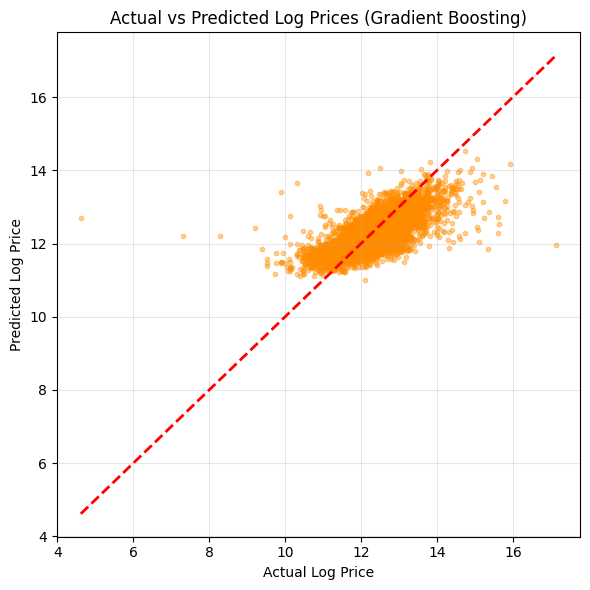

In [5]:
# GradientBoostingRegressor_model.ipynb
# Predictive Model: Gradient Boosting Regressor for Log House Prices

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from config import PROCESSED_DIR

# -----------------------------
# 1. Load Dataset
# -----------------------------
data_path = PROCESSED_DIR / "uk_housing_2010_2017_processed.csv"
df = pd.read_csv(data_path, low_memory=False)
print(f"Loaded {len(df):,} rows and {df.shape[1]} columns")

# Sample subset for faster computation
df_sample = df.sample(50_000, random_state=42).copy()
print(f"Using sample: {len(df_sample):,} rows")

# -----------------------------
# 2. Define Features and Target
# -----------------------------
possible_features = ["year", "month", "property_type", "county", "district", "town_city"]
features = [f for f in possible_features if f in df_sample.columns]
target = "log_price"

X = df_sample[features]
y = df_sample[target]
print("Features used:", features)

# -----------------------------
# 3. Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------------
# 4. Preprocessing
# -----------------------------
num_features = [f for f in ["year", "month"] if f in X_train.columns]
cat_features = [f for f in X_train.columns if f not in num_features]

num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_features),
    ("cat", cat_pipe, cat_features)
])

# -----------------------------
# 5. Build Model
# -----------------------------
model = Pipeline([
    ("prep", preprocessor),
    ("gbr", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        random_state=42
    ))
])

print("Training Gradient Boosting Regressor...")
model.fit(X_train, y_train)
print("Model training complete.")

# -----------------------------
# 6. Evaluation
# -----------------------------
from math import sqrt
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nEvaluation Metrics:")
print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²  : {r2:.3f}")

# -----------------------------
# 7. Visualize Actual vs Predicted
# -----------------------------
figures_dir = PROCESSED_DIR.parent / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.4, s=10, color="darkorange")
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
ax.set_title("Actual vs Predicted Log Prices (Gradient Boosting)")
ax.set_xlabel("Actual Log Price")
ax.set_ylabel("Predicted Log Price")
ax.grid(alpha=0.3)
plt.tight_layout()

plot_path = figures_dir / "gbr_actual_vs_predicted.png"
fig.savefig(plot_path, dpi=300)
print(f"Saved plot: {plot_path}")
plt.show()


Loaded 5,944,841 rows and 14 columns
Using sample: 50,000 rows
Training Gradient Boosting Regressor...
Model training complete.

Evaluation Metrics:
Train MAE : 0.320, Test MAE : 0.327
Train RMSE: 0.448, Test RMSE: 0.462
Train R²  : 0.585, Test R²  : 0.542

5-Fold CV R² mean: 0.536 ± 0.010


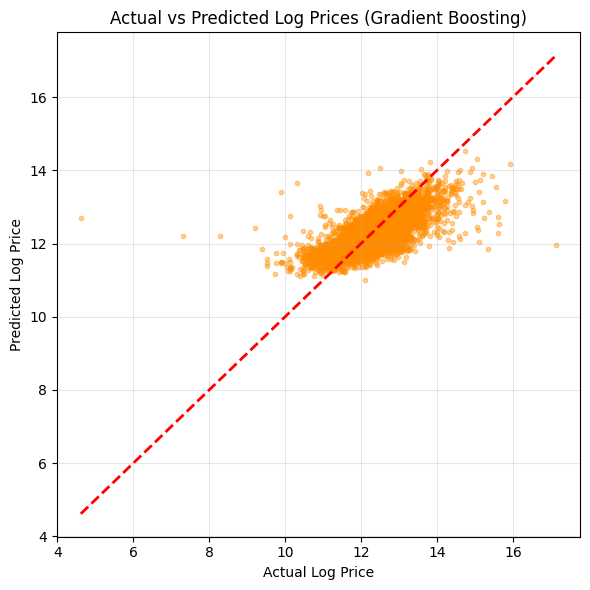

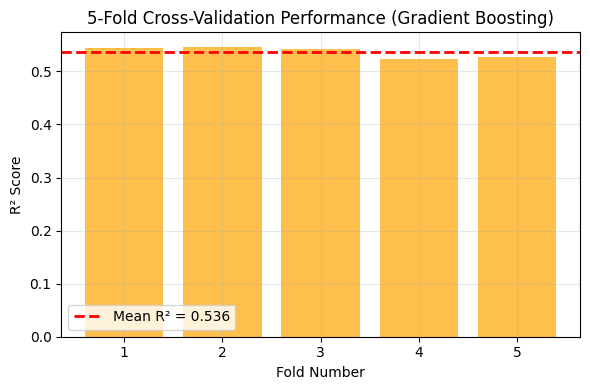

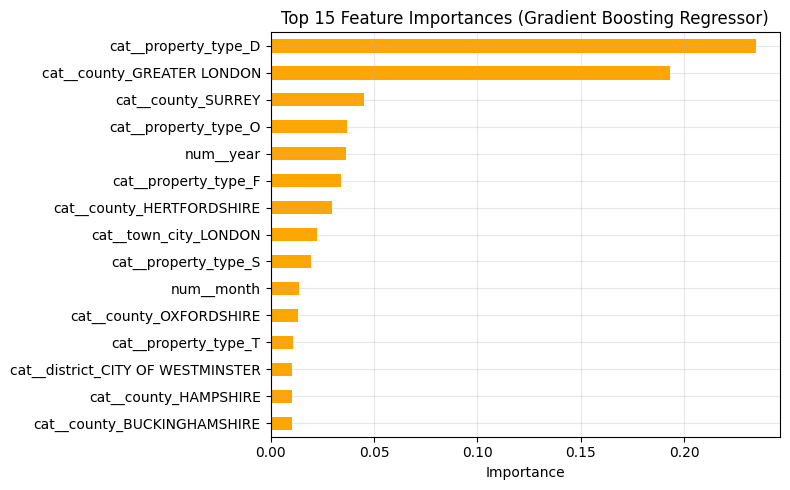

In [6]:
# Gradient Boosting Regression

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from math import sqrt
from config import PROCESSED_DIR

# Load dataset
data_path = PROCESSED_DIR / "uk_housing_2010_2017_processed.csv"
df = pd.read_csv(data_path, low_memory=False)
print(f"Loaded {len(df):,} rows and {df.shape[1]} columns")

df_sample = df.sample(50_000, random_state=42).copy()
print(f"Using sample: {len(df_sample):,} rows")

# Features and Target
features = ["year", "month", "property_type", "county", "district", "town_city"]
target = "log_price"

X = df_sample[features]
y = df_sample[target]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Preprocessing
num_features = ["year", "month"]
cat_features = [f for f in X_train.columns if f not in num_features]

num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_features),
    ("cat", cat_pipe, cat_features)
])

# Model
model = Pipeline([
    ("prep", preprocessor),
    ("gbr", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        random_state=42
    ))
])

print("Training Gradient Boosting Regressor...")
model.fit(X_train, y_train)
print("Model training complete.")

# Evaluation
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_train = sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = sqrt(mean_squared_error(y_test, y_pred_test))
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print("\nEvaluation Metrics:")
print(f"Train MAE : {mae_train:.3f}, Test MAE : {mae_test:.3f}")
print(f"Train RMSE: {rmse_train:.3f}, Test RMSE: {rmse_test:.3f}")
print(f"Train R²  : {r2_train:.3f}, Test R²  : {r2_test:.3f}")

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = []

for train_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)
    cv_r2.append(r2_score(y_val, preds))

cv_mean = np.mean(cv_r2)
cv_std = np.std(cv_r2)
print(f"\n5-Fold CV R² mean: {cv_mean:.3f} ± {cv_std:.3f}")

# Save all plots
figures_dir = PROCESSED_DIR.parent / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

# Actual vs Predicted
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_test, alpha=0.4, s=10, color="darkorange")
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
ax.set_title("Actual vs Predicted Log Prices (Gradient Boosting)")
ax.set_xlabel("Actual Log Price")
ax.set_ylabel("Predicted Log Price")
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(figures_dir / "gbr_actual_vs_predicted.png", dpi=300)
plt.show()

# Cross-Validation Performance Plot
plt.figure(figsize=(6,4))
plt.bar(range(1, 6), cv_r2, color="orange", alpha=0.7)
plt.axhline(cv_mean, color="red", linestyle="--", linewidth=2, label=f"Mean R² = {cv_mean:.3f}")
plt.xlabel("Fold Number")
plt.ylabel("R² Score")
plt.title("5-Fold Cross-Validation Performance (Gradient Boosting)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / "gbr_crossval_r2.png", dpi=300)
plt.show()

# Feature Importance
gbr_model = model.named_steps["gbr"]
feature_names = model.named_steps["prep"].get_feature_names_out()
feat_imp = pd.Series(gbr_model.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(8,5))
feat_imp.plot(kind="barh", color="orange")
plt.title("Top 15 Feature Importances (Gradient Boosting Regressor)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / "gbr_feature_importances.png", dpi=300)
plt.show()
